<a href="https://colab.research.google.com/github/Akritz2004/ProjectStock-Energy-Banking-Retail-/blob/main/StockProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance
!pip install pandas_ta
!pip install --upgrade scikit-learn scipy

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [ ]:
interesting_tickers = ["PTT.BK", "CPALL.BK", "KBANK.BK"]
df = yf.download(interesting_tickers, period="5y")['Close']

/tmp/ipykernel_9084/1839076495.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(interesting_tickers, period="5y")['Close']
[*********************100%***********************]  3 of 3 completed


In [ ]:
df

Ticker,CPALL.BK,KBANK.BK,PTT.BK
Date,,,
2021-04-12,58.885818,111.999977,28.830688
2021-04-16,59.116745,108.765335,29.385134
2021-04-19,59.347672,110.786987,29.385134
2021-04-20,60.040440,115.317322,29.385134
2021-04-21,59.347672,115.317322,29.015507
...,...,...,...
2026-04-03,45.500000,190.500000,34.250000
2026-04-07,45.250000,191.500000,34.750000
2026-04-08,47.250000,193.000000,35.000000


In [ ]:
##การเปลี่ยนแปลงรายวัน
returns_df = df.pct_change().dropna()
returns_df

Ticker,CPALL.BK,KBANK.BK,PTT.BK
Date,,,
2021-04-16,0.003922,-0.028881,0.019231
2021-04-19,0.003906,0.018587,0.000000
2021-04-20,0.011673,0.040892,0.000000
2021-04-21,-0.011538,0.000000,-0.012579
2021-04-22,-0.011673,-0.021429,-0.006370
...,...,...,...
2026-04-03,0.000000,-0.007812,-0.035211
2026-04-07,-0.005495,0.005249,0.014599
2026-04-08,0.044199,0.007833,0.007194


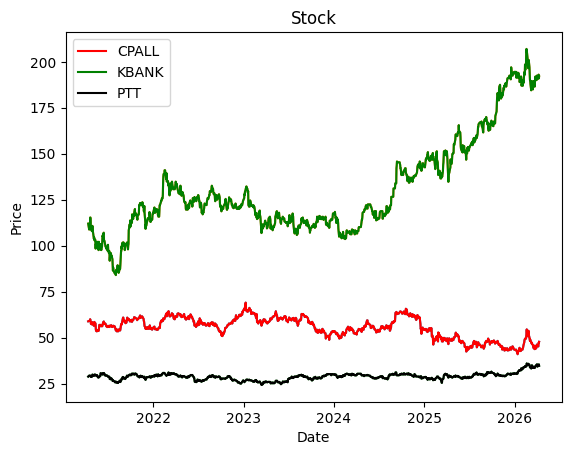

In [ ]:
plt.plot(df)
plt.plot(df['CPALL.BK'], label='CPALL', color = 'red')
plt.plot(df['KBANK.BK'], label='KBANK',color = 'green')
plt.plot(df['PTT.BK'], label='PTT', color = 'black')
plt.title('Stock')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

###หมายเหตุ หากค่าเปลี่ยนไปจากเดิม เหตุผลมาจากการที่โหลดข้อมูลแบบ Realtime พอรันใหม่ทำให้เลขเปลี่ยนไปเรื่อยๆ

หากสังเกตุราคา น้ำมันของ PTT ดีๆ จะเห็นว่ามีการเพิ่มสูงขึ้นกว่า 4ปี ที่ผ่านมา เนื่องจากอยู่ในช่วงสภาวะสงครามทำให้เราสังเกตุเห็นได้ง่าย และอาจเป็นตัวแปรที่ส่งผลต่อหุ้นตัวอื่นๆ เนื่องจากน้ำมันเป็นสิ่งสำคัญ ในการดำเนินธุรกิจต่างๆ

###สนใจหุ้น PTT

In [ ]:
df_ptt_full = yf.download("PTT.bk", period="5y")
df_ptt_full = df_ptt_full.xs('PTT.BK', axis=1, level=1)
df_ptt_full

/tmp/ipykernel_9084/3029425550.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_ptt_full = yf.download("PTT.bk", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,28.830692,29.200317,28.645880,29.015504,37609500
2021-04-16,29.385132,29.569944,29.015508,29.200320,60260500
2021-04-19,29.385132,29.569944,29.200320,29.385132,30128300
2021-04-20,29.385132,29.754756,29.200320,29.385132,34410000
2021-04-21,29.015505,29.200317,28.830693,29.200317,40084200
...,...,...,...,...,...
2026-04-03,34.250000,35.500000,34.250000,35.500000,96794300
2026-04-07,34.750000,35.250000,34.000000,34.250000,90396600
2026-04-08,35.000000,35.250000,34.250000,34.500000,73033000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

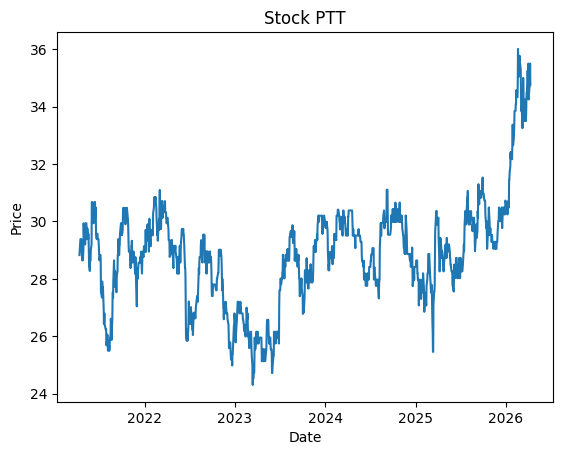

In [ ]:
plt.plot(df_ptt_full['Close'])
plt.title('Stock PTT')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [ ]:
print(df_ptt_full['Volume'].head())

Date
2021-04-12    37609500
2021-04-16    60260500
2021-04-19    30128300
2021-04-20    34410000
2021-04-21    40084200
Name: Volume, dtype: int64


จากกราฟช่วงก่อน 2022 มีราคาหุ้นที่ปกติ แต่เนนื่องจากในปี 2026 เกิดสภาวะสงคราม และสภาพเศรฐกิจ ทำให้ราคาเกิดการผันผวน

กำหนด Y = ราคาขึ้นหรือลง ขึ้นคือ 1 ลงหรือเท่าเดิมคือ 0
กำหนด X = RSI,MACD, MA, Volume, Volatility

*   RSI (Relative Strength Index) คือ เครื่องมือทางเทคนิคที่ใช้วัด "ความแข็งแกร่ง" ของราคาหุ้นหรือสินทรัพย์ เพื่อดูว่ามีการซื้อมากเกินไป (Overbought) หรือขายมากเกินไป (Oversold)
*   MACD (Moving Average Convergence Divergence) คือ เครื่องมือทางเทคนิคที่ช่วยดู ทิศทางแนวโน้ม (Trend) และ แรงส่งของราคา (Momentum)

*   MA (Moving Average) หรือ SMA 20 (Simple Moving Average 20) คือ เครื่องมือทางเทคนิคที่นำราคาปิดย้อนหลังมาหาค่าเฉลี่ย เพื่อทำให้กราฟหุ้นดูเรียบเนียนขึ้น ตัดความผันผวนระหว่างวันออกไป ช่วยให้มองเห็น "แนวโน้ม (Trend)" ชัดเจนว่าหุ้นเป็นขาขึ้น ขาลง หรือออกข้าง นิยมใช้ดูแนวรับ-แนวต้าน และสัญญาณซื้อ-ขาย
*   Volume คือ ปริมาณการซื้อขาย คือจำนวนหุ้น (หรือสัญญา) ทั้งหมดที่มีการจับคู่ซื้อขายกันจริงในช่วงเวลาหนึ่งๆ เป็นดัชนีชี้วัดความสนใจของนักลงทุน หาก Volume สูงแปลว่าคนกำลังสนใจหุ้นตัวนั้นมาก หากต่ำแปลว่าคนสนใจน้อย โดยมักดูควบคู่กับราคาร่วมกับกราฟเทคนิคเพื่อวิเคราะห์แนวโน้ม
*   Volatility คือ ตัวชี้วัดว่าราคาสินทรัพย์ (เช่น หุ้น, ทองคำ, คริปโต) มีการแกว่งตัวขึ้นลงเร็วและแรงแค่ไหนในช่วงเวลาหนึ่ง ยิ่งราคาเคลื่อนไหวแรงและบ่อย แปลว่ามีความผันผวนสูง (เสี่ยงสูง/ทำกำไรได้มาก) หากราคาขยับช้าๆ นิ่งๆ คือความผันผวนต่ำ


In [ ]:
df_ptt = df_ptt_full.copy() #สร้าง DataFrame บน Table เดิม
df_ptt.rename(columns={"PTT.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_ptt['RSI'] = ta.rsi(df_ptt['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_ptt = ta.macd(df_ptt['Close'])
df_ptt['MACD'] = macd_ptt['MACD_12_26_9']
df_ptt['MACD_Signal'] = macd_ptt['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน
# Corrected to use df_ptt['Close'] instead of df['Close']
df_ptt['SMA_20'] = ta.sma(df_ptt['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_ptt['Volatility'] = df_ptt['Close'].rolling(window=20).std()

df_ptt['Vol_SMA'] = df_ptt['Volume'].rolling(window=20).mean()
df_ptt['Relative_Volume'] = df_ptt['Volume'] / df_ptt['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_ptt['Target'] = (df_ptt['Close'].shift(-1) > df_ptt['Close']).astype(int)
df_ptt.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_ptt.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_ptt.head())

Price           Close    Volume        RSI      MACD  MACD_Signal     SMA_20  \
Date                                                                           
2021-06-07  30.494001  65914800  69.741720  0.240026    -0.033344  29.505259   
2021-06-08  29.939569  49609300  61.550492  0.235804     0.020486  29.505259   
2021-06-09  30.124374  36053500  63.105965  0.244551     0.065299  29.514499   
2021-06-10  30.124374  28605300  63.105965  0.248617     0.101963  29.532980   
2021-06-11  30.678816  38833600  67.658409  0.293199     0.140210  29.597664   

Price       Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                         
2021-06-07    0.730135  72493875.0         0.909246       0  
2021-06-08    0.730135  72814245.0         0.681313       1  
2021-06-09    0.737057  72648240.0         0.496275       0  
2021-06-10    0.747952  71796080.0         0.398424       1  
2021-06-11    0.789290  70848595.0         0.548121       0  


In [ ]:
print(df_ptt.columns)

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')


In [ ]:
split_index = int(len(df_ptt) * 0.8)
train_df = df_ptt.iloc[:split_index]
test_df = df_ptt.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [ ]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


##Random Forest For PTT

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
modelRF_PTT = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_PTT.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_PTT = modelRF_PTT.predict(X_test)

In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_PTT))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.63      0.95      0.76       148
           1       0.47      0.08      0.14        88

    accuracy                           0.62       236
   macro avg       0.55      0.51      0.45       236
weighted avg       0.57      0.62      0.53       236



Feature Importances:
           Feature  Importance
3           SMA_20    0.207761
0  Relative_Volume    0.206125
2             MACD    0.202927
4       Volatility    0.200066
1              RSI    0.183121


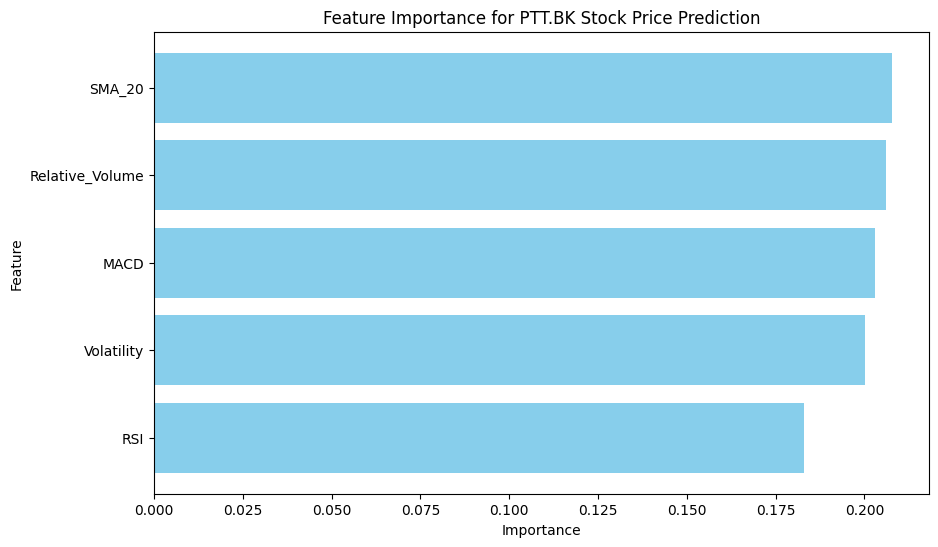

In [ ]:
feature_importances = modelRF_PTT.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PTT.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (PTT) : <br>
MACD = 0.205 <br>
Volatility = 0.204 <br>
Relative Volume = 0.203 <br>
SMA = 0.199 <br>
RSI = 0.187<br>
Accuracy = 62%

จากการวิเคราะห์ Feature Importance พบว่าโมเดลให้ความสำคัญกับ MACD และ Volatility สูงที่สุด สะท้อนให้เห็นว่าราคาหุ้น PTT มีพฤติกรรมเคลื่อนที่ตามแนวโน้มแรงเฉื่อย (Trend-Following) และมีความไวต่อสภาวะความเสี่ยงในตลาด ดังนั้นการพยากรณ์ด้วยเทคนิคเพียงอย่างเดียวอาจไม่เพียงพอ จำเป็นต้องนำข้อมูลเชิงคุณภาพ (Qualitative Data) เช่น ข่าวเศรษฐกิจมหภาคและราคาน้ำมันโลกมาวิเคราะห์ร่วมด้วย เพื่อลดช่องว่างความผิดพลาดในช่วงที่ตลาดมีความผันผวนสูงผิดปกติ

##XGBoost For PTT

In [ ]:
from xgboost import XGBClassifier

In [ ]:
modelXG_PTT = XGBClassifier(n_estimators=100, random_state=42)
modelXG_PTT.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_PTT = modelXG_PTT.predict(X_test)


In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_PTT))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.63      0.94      0.76       148
           1       0.47      0.09      0.15        88

    accuracy                           0.62       236
   macro avg       0.55      0.52      0.45       236
weighted avg       0.57      0.62      0.53       236



Feature Importances:
           Feature  Importance
2             MACD    0.214049
3           SMA_20    0.203671
1              RSI    0.197787
4       Volatility    0.193254
0  Relative_Volume    0.191239


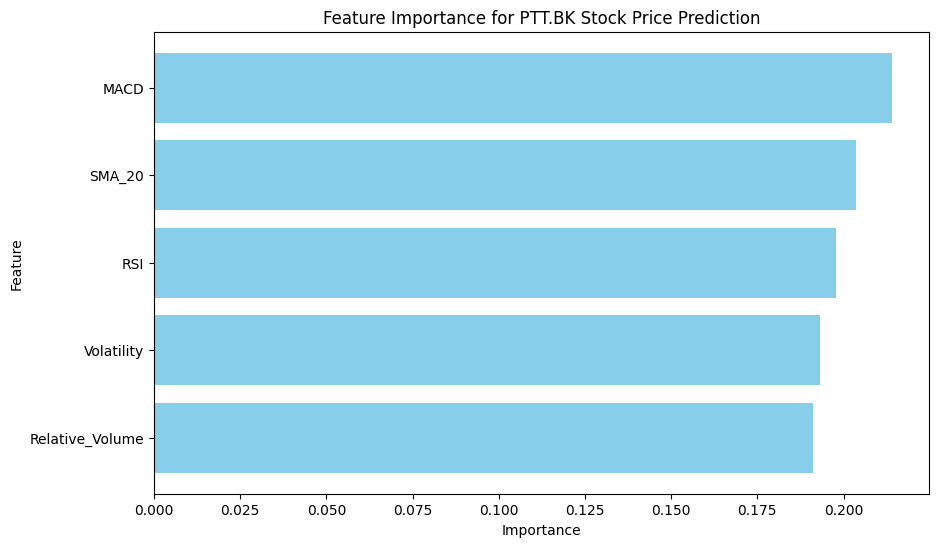

In [ ]:
feature_importances = modelXG_PTT.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PTT.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (PTT) : <br>
SMA = 0.221 <br>
MACD = 0.215 <br>
RSI = 0.202 <br>
Relative Volume = 0.191 <br>
Volatility = 0.169 <br>
Accuracy = 59%

จากการวัด Accuracy RandomForest มีความแม่นยำกว่า แต่ในตัวของ XGBoost กลับให้ความสำคัญกับ SMA และ RSI ด้วย ซึ่งเป็นเครื่องมือในการวัดเทรนและ การซื้อ-ขาย ของหุ้นที่มากเกินหรือน้อยเกิน ทำให้เราสามารถจับสังเกตุและนำไปใช้งานต่อได้ง่ายกว่า แม้ RSI จะเป็นอันดับ 3 แต่ MACD ก็เป็นอันดับ 2 ทำให่เรายังจำเป็นต้องจับจังหวะการแกว่งตัวของราคาอยู่บ้าง

####สนใจหุ้น KBANK

In [ ]:
df_kbank_full = yf.download("KBANK.BK", period="5y")
df_kbank_full = df_kbank_full.xs('KBANK.BK', axis=1, level=1)
df_kbank_full

/tmp/ipykernel_9084/1974678290.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_kbank_full = yf.download("KBANK.BK", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,111.999977,114.425969,111.595645,114.021637,18151500
2021-04-16,108.765312,110.382640,107.552316,109.978308,33938200
2021-04-19,110.786972,110.786972,108.765312,109.573976,20513200
2021-04-20,115.317322,116.964712,109.139608,111.198846,37233200
2021-04-21,115.317322,115.729169,113.669931,114.905474,21384700
...,...,...,...,...,...
2026-04-03,190.500000,192.000000,190.000000,192.000000,11180200
2026-04-07,191.500000,192.000000,190.000000,191.000000,6165500
2026-04-08,193.000000,194.000000,192.500000,193.000000,11115400


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

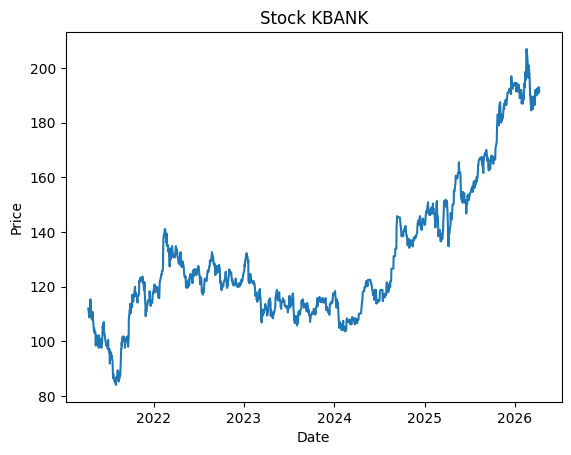

In [ ]:
plt.plot(df_kbank_full['Close'])
plt.title('Stock KBANK')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [ ]:
df_kbank = df_kbank_full.copy()
df_kbank.rename(columns={"KBANK.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_kbank['RSI'] = ta.rsi(df_kbank['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_kbank = ta.macd(df_kbank['Close'])
df_kbank['MACD'] = macd_kbank['MACD_12_26_9']
df_kbank['MACD_Signal'] = macd_kbank['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน

df_kbank['SMA_20'] = ta.sma(df_kbank['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_kbank['Volatility'] = df_kbank['Close'].rolling(window=20).std()

df_kbank['Vol_SMA'] = df_kbank['Volume'].rolling(window=20).mean()
df_kbank['Relative_Volume'] = df_kbank['Volume'] / df_kbank['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_kbank['Target'] = (df_kbank['Close'].shift(-1) > df_kbank['Close']).astype(int)
df_kbank.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_kbank.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_kbank.head())

Price            Close    Volume        RSI      MACD  MACD_Signal  \
Date                                                                 
2021-06-07   99.667099  30478500  37.987930 -2.961492    -3.556395   
2021-06-08  102.550041  48686900  44.316829 -2.516768    -3.348469   
2021-06-09  105.432968  70033900  49.830880 -1.909679    -3.060711   
2021-06-10  105.021118  51261200  49.083108 -1.445131    -2.737595   
2021-06-11  106.256668  22388700  51.437493 -0.966138    -2.383304   

Price           SMA_20  Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                                     
2021-06-07  100.202509    1.822836  37142735.0         0.820578       1  
2021-06-08  100.181917    1.792090  37979535.0         1.281925       1  
2021-06-09  100.284878    2.028662  40594495.0         1.725207       0  
2021-06-10  100.387840    2.215347  42068550.0         1.218516       1  
2021-06-11  100.779095    2.521508  40667960.0         0.550524  

In [ ]:
df_kbank.columns

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')

In [ ]:
split_index = int(len(df_kbank) * 0.8)
train_df = df_kbank.iloc[:split_index]
test_df = df_kbank.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [ ]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


##Random Forest (KBank)

In [ ]:
modelRF_kbank = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_kbank.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_kbank = modelRF_kbank.predict(X_test)

In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_kbank))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.55      0.90      0.68       131
           1       0.41      0.09      0.14       105

    accuracy                           0.54       236
   macro avg       0.48      0.49      0.41       236
weighted avg       0.49      0.54      0.44       236



Feature Importances:
           Feature  Importance
4       Volatility    0.218661
1              RSI    0.201962
2             MACD    0.198885
3           SMA_20    0.192752
0  Relative_Volume    0.187741


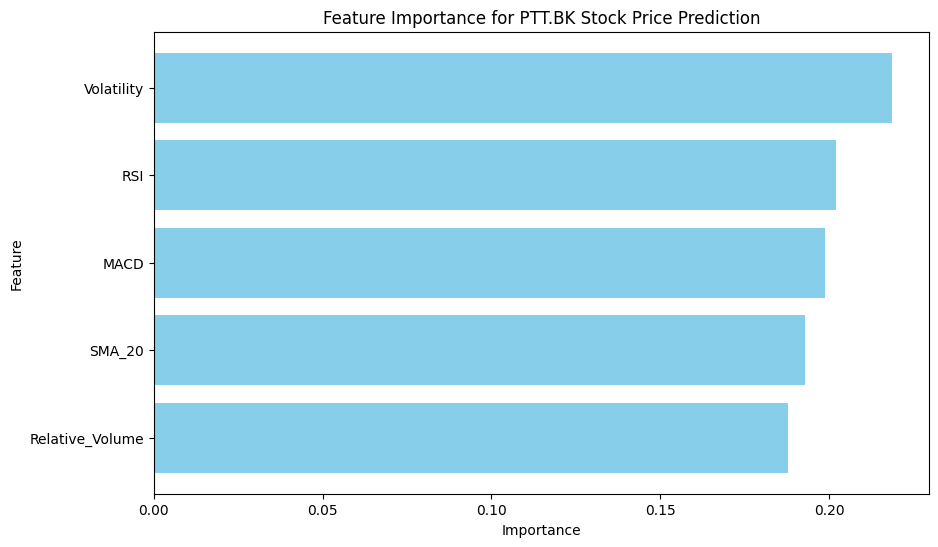

In [ ]:
feature_importances = modelRF_kbank.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for KBANK.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (Kbank) : <br>
Volatility = 0.220 <br>
MACD = 0.1997 <br>
RSI = 0.1994 <br>
SMA = 0.193 <br>
Relative Volume = 0.187 <br>
Accuracy = 56%

โมเดล RandomForest พยากรณ์ PTT ได้แม่นยำกว่า KBANK (61% vs 56%) เนื่องจาก PTT มีทิศทางตามราคาน้ำมันและเทรนที่ชัดเจนกว่า ขณะที่ KBANK ให้ความสำคัญกับ Volatility สูงที่สุด สะท้อนถึงความไวต่อสภาวะความเสี่ยงของระบบเศรษฐกิจ ซึ่งเป็นปัจจัยที่มีความซับซ้อนและมี Noise สูงกว่า เนื่องจากยังมีตัวแปรที่ไม่ได้นำเข้ามานับเช่น ค่าเงินบาท, นโยบายธนาคารกลาง (Bot) หรือภาพรวมเศรษฐกิจ เป็นต้น

##XGBoost (KBank)

In [ ]:
modelXG_kbank = XGBClassifier(n_estimators=100, random_state=42)
modelXG_kbank.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predXG_kbank = modelXG_kbank.predict(X_test)


In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predXG_kbank))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.56      0.98      0.71       131
           1       0.60      0.03      0.05       105

    accuracy                           0.56       236
   macro avg       0.58      0.51      0.38       236
weighted avg       0.58      0.56      0.42       236



Feature Importances:
           Feature  Importance
4       Volatility    0.213102
0  Relative_Volume    0.211959
2             MACD    0.204932
3           SMA_20    0.186708
1              RSI    0.183299


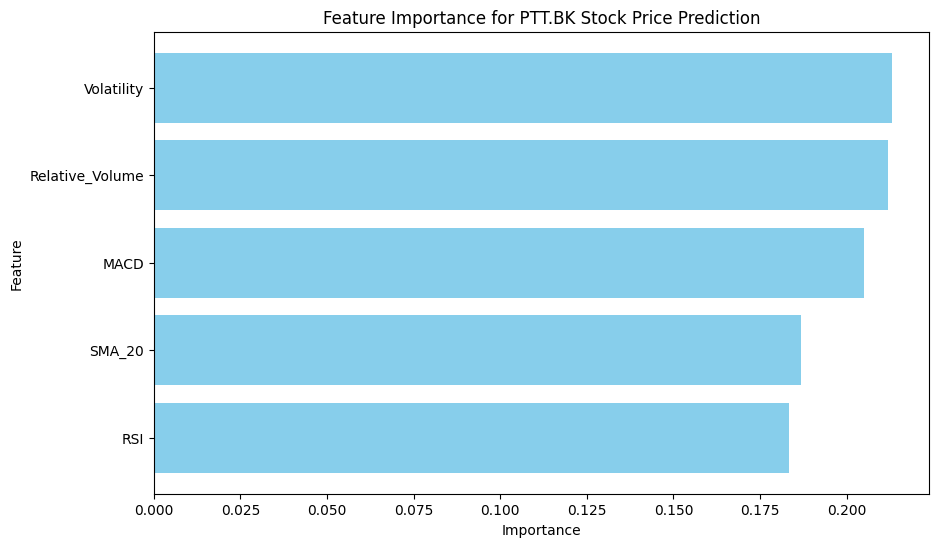

In [ ]:
feature_importances = modelXG_kbank.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for KBANK.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (Kbank) : <br>
MACD = 0.214 <br>
Volatility = 0.202 <br>
SMA = 0.198 <br>
RSI = 0.195 <br>
Relative Volume = 0.188 <br>
Accuracy = 55%

สำหรับหุ้น KBANK ทั้งสองโมเดลให้ผลลัพธ์ใกล้เคียงกันที่ 55-56% โดยมีค่าความสำคัญของตัวแปรเกาะกลุ่มกันชัดเจนในด้าน Momentum (MACD) และ ความเสี่ยง (Volatility) ซึ่งสะท้อนพฤติกรรมของหุ้นกลุ่มธนาคารที่เคลื่อนไหวตามสภาวะเศรษฐกิจ อย่างไรก็ตาม ความแม่นยำที่น้อยกว่าหุ้นกลุ่มอื่นแสดงให้เห็นว่า ปัจจัยทางเทคนิคเพียงอย่างเดียวอาจไม่เพียงพอ การเพิ่มตัวแปรด้านมหภาค เช่น อัตราดอกเบี้ย หรือ Yield Curve อาจช่วยเพิ่มประสิทธิภาพในการพยากรณ์ได้มากกว่านี้

###สนใจหุ้น CPALL

In [ ]:
df_cpall_full = yf.download("CPALL.BK", period="5y")
df_cpall_full = df_cpall_full.xs('CPALL.BK', axis=1, level=1)
df_cpall_full

/tmp/ipykernel_9084/2294739579.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_cpall_full = yf.download("CPALL.BK", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,58.885818,60.040442,58.654894,59.809518,32020800
2021-04-16,59.116745,59.578595,58.654895,59.347670,31473500
2021-04-19,59.347675,59.809525,59.116751,59.116751,18793100
2021-04-20,60.040447,60.271372,59.347673,59.578598,27266700
2021-04-21,59.347675,60.040450,59.347675,59.809525,13111200
...,...,...,...,...,...
2026-04-03,45.500000,46.250000,45.500000,45.750000,33660300
2026-04-07,45.250000,45.500000,45.000000,45.500000,20459900
2026-04-08,47.250000,47.500000,46.000000,46.500000,50052800


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

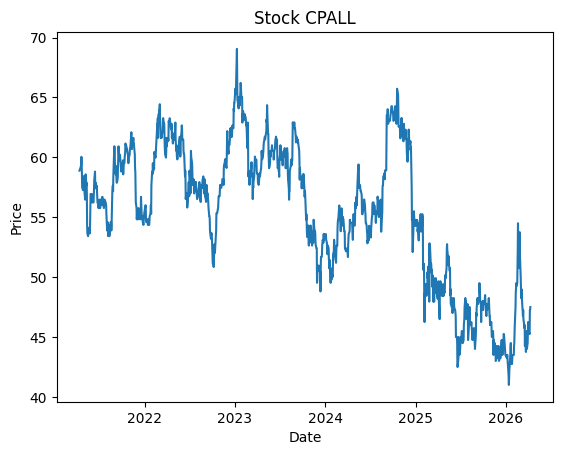

In [ ]:
plt.plot(df_cpall_full['Close'])
plt.title('Stock CPALL')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [ ]:
df_cpall = df_cpall_full.copy()
df_cpall.rename(columns={"CPALL.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_cpall['RSI'] = ta.rsi(df_cpall['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_cpall = ta.macd(df_cpall['Close'])
df_cpall['MACD'] = macd_cpall['MACD_12_26_9']
df_cpall['MACD_Signal'] = macd_cpall['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน

df_cpall['SMA_20'] = ta.sma(df_cpall['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_cpall['Volatility'] = df_cpall['Close'].rolling(window=20).std()

df_cpall['Vol_SMA'] = df_cpall['Volume'].rolling(window=20).mean()
df_cpall['Relative_Volume'] = df_cpall['Volume'] / df_cpall['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_cpall['Target'] = (df_cpall['Close'].shift(-1) > df_cpall['Close']).astype(int)
df_cpall.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_cpall.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_cpall.head())

Price           Close    Volume        RSI      MACD  MACD_Signal     SMA_20  \
Date                                                                           
2021-06-07  56.231686  11574800  51.542732 -0.609019    -1.162891  55.622508   
2021-06-08  56.231686  17748400  51.542732 -0.544844    -1.039282  55.505359   
2021-06-09  56.934578  19272900  56.512634 -0.432285    -0.917882  55.470214   
2021-06-10  57.871777  31085400  62.094940 -0.264408    -0.787187  55.470214   
2021-06-11  58.106075  21782500  63.361177 -0.111178    -0.651985  55.528788   

Price       Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                         
2021-06-07    1.708935  31577160.0         0.366556       0  
2021-06-08    1.570619  30846170.0         0.575384       1  
2021-06-09    1.527676  31014075.0         0.621424       1  
2021-06-10    1.527676  31628785.0         0.982820       1  
2021-06-11    1.607169  31758960.0         0.685869       1  


In [ ]:
df_cpall.columns

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')

In [ ]:
split_index = int(len(df_cpall) * 0.8)
train_df = df_cpall.iloc[:split_index]
test_df = df_cpall.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [ ]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


Random Forest (CPALL)

In [ ]:
modelRF_cpall = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_cpall.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_cpall = modelRF_cpall.predict(X_test)

In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_cpall))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.55      0.42      0.47       134
           1       0.42      0.55      0.47       102

    accuracy                           0.47       236
   macro avg       0.48      0.48      0.47       236
weighted avg       0.49      0.47      0.47       236



Feature Importances:
           Feature  Importance
4       Volatility    0.202772
1              RSI    0.202745
3           SMA_20    0.201365
0  Relative_Volume    0.199664
2             MACD    0.193453


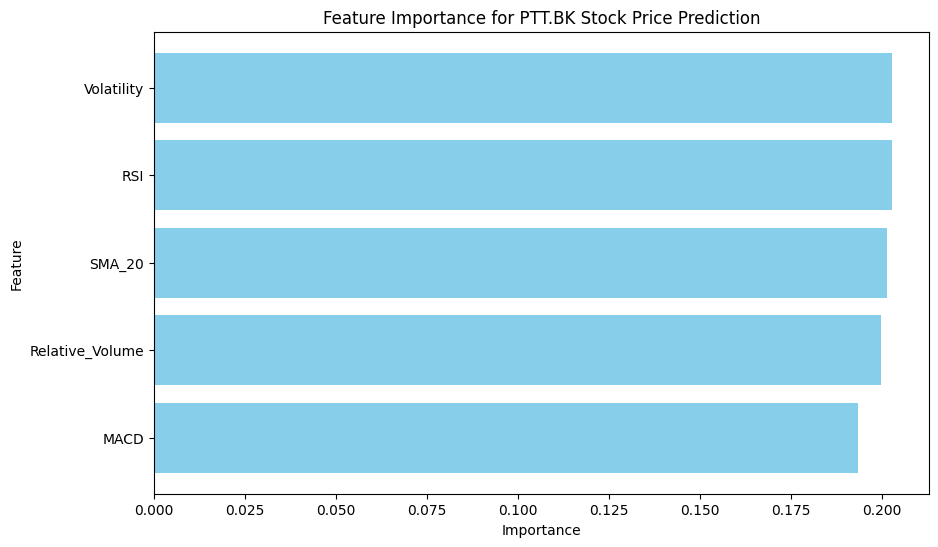

In [ ]:
feature_importances = modelRF_cpall.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for CPALL.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (Cpall) : <br>
Volatility = 0.203 <br>
MACD = 0.193 <br>
RSI = 0.202 <br>
SMA = 0.201 <br>
Relative Volume = 0.199 <br>
Accuracy = 47%

จากการทดสอบกับหุ้น CPALL พบว่าโมเดลให้ความแม่นยำเพียง 47% ซึ่งต่ำกว่าหุ้นในกลุ่มพลังงานและธนาคาร สะท้อนให้เห็นว่า พฤติกรรมราคาของหุ้นกลุ่มค้าปลีกมีความซับซ้อนและไม่ได้เคลื่อนที่ตามปัจจัยทางเทคนิคเป็นหลัก (Non-technical driven) โดยค่า Feature Importance ที่เกาะกลุ่มกันอย่างใกล้ชิดบ่งบอกว่าไม่มีอินดิเคเตอร์ตัวใดตัวหนึ่งที่สามารถเป็นตัวชี้นำราคาได้ชัดเจน (Lack of leading indicators) ดังนั้นในหุ้นลักษณะนี้ การใช้เพียง Technical Analysis จึงไม่เพียงพอ และจำเป็นต้องเพิ่มตัวแปรด้านเศรษฐกิจมหภาคหรือข้อมูลการบริโภคในประเทศเข้ามาเสริมเพื่อให้โมเดลเรียนรู้ Pattern ได้ดียิ่งขึ้น

##XGBoost (CPALL)

In [ ]:
modelXG_cpall = XGBClassifier(n_estimators=100, random_state=42)
modelXG_cpall.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predXG_cpall = modelXG_cpall.predict(X_test)


In [ ]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predXG_cpall))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.61      0.55      0.58       134
           1       0.47      0.53      0.50       102

    accuracy                           0.54       236
   macro avg       0.54      0.54      0.54       236
weighted avg       0.55      0.54      0.54       236



Feature Importances:
           Feature  Importance
1              RSI    0.209598
3           SMA_20    0.200308
4       Volatility    0.198772
0  Relative_Volume    0.197485
2             MACD    0.193838


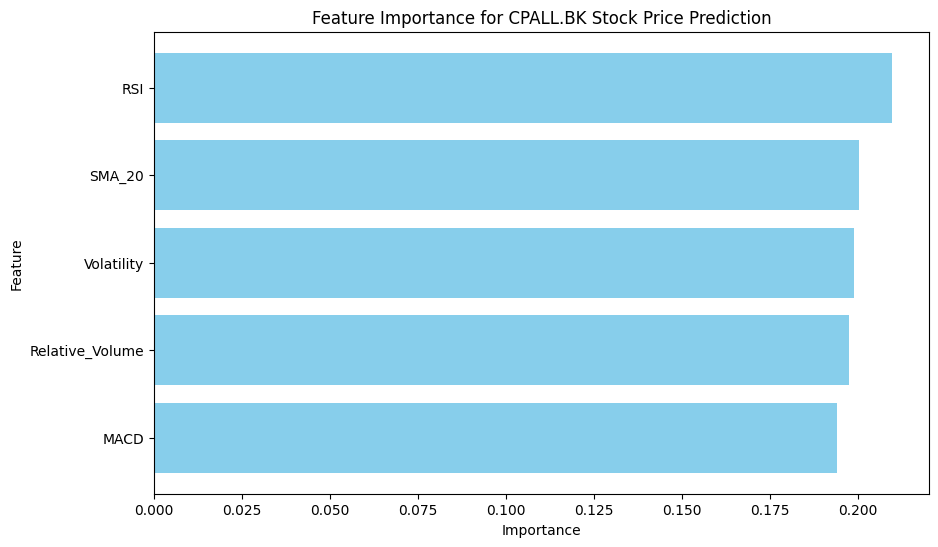

In [ ]:
feature_importances = modelXG_cpall.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for CPALL.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (Cpall) : <br>
RSI = 0.209 <br>
SMA = 0.200 <br>
Relative Volume = 0.197 <br>
Volatility = 0.198 <br>
MACD = 0.193 <br>
Accuracy = 54%

แม้ CPALL จะมีความผันผวนของราคาที่จับทางได้ยากในระยะสั้น แต่การที่ RSI และ SMA พุ่งขึ้นมาเป็นปัจจัยหลักในโมเดล XGBoost แสดงให้เห็นว่าหุ้นตัวนี้ยังคงเคลื่อนที่ตามปัจจัยทางเทคนิคพื้นฐาน (Technical Driven) ในระดับหนึ่ง โดยเฉพาะจังหวะการย่อตัวเพื่อไปต่อตามแนวโน้มเดิม

จากการศึกษาพบว่าหุ้นในแต่ละกลุ่มอุตสาหกรรมมีพฤติกรรมข้อมูลที่ต่างกัน หุ้นที่มีความสัมพันธ์กับปัจจัยภายนอกชัดเจนอย่าง PTT สามารถพยากรณ์ได้แม่นยำที่สุด ในขณะที่หุ้นกลุ่มค้าปลีกอย่าง CPALL มีความซับซ้อนสูงกว่าและจำเป็นต้องใช้โมเดลขั้นสูงอย่าง XGBoost เพื่อจับสัญญาณการกลับตัว (RSI) และแนวโน้ม (SMA) จึงจะให้ผลลัพธ์ที่มีนัยสำคัญ